总波浪数: 18
波浪高度阈值(前20%): 3.0900
所有波浪高度范围: ['4.1900', '4.0200', '3.0900', '1.8100', '1.7900', '1.5700', '1.4900', '1.3300', '1.2800', '1.2800', '1.2700', '1.1700', '1.0800', '1.0700', '1.0300', '0.9600', '0.7400', '0.5500']

检查位置: 波1(down), 高度: 0.5500
  三波检查 - 上升: False, 下降: False
  单波高度 0.5500 < 阈值 3.0900，不符合
  未找到推动段，滑动到波2

检查位置: 波2(up), 高度: 1.5700
  三波检查 - 上升: False, 下降: False
  单波高度 1.5700 < 阈值 3.0900，不符合
  未找到推动段，滑动到波3

检查位置: 波3(down), 高度: 1.0800
  三波检查 - 上升: False, 下降: False
  单波高度 1.0800 < 阈值 3.0900，不符合
  未找到推动段，滑动到波4

检查位置: 波4(up), 高度: 0.9600
  三波检查 - 上升: True, 下降: False
    扩展段过冲容忍: 波6到波8
  找到正常三波推动段: up1, 跳到波9

检查位置: 波9(down), 高度: 1.4900
  三波检查 - 上升: False, 下降: False
  应用反向段过冲容忍
    下降容忍通过: 条件1=True, 条件2=False
  找到正常三波推动段: down1, 跳到波12

检查位置: 波12(up), 高度: 1.1700
  三波检查 - 上升: False, 下降: False
  应用反向段过冲容忍
  单波高度 1.1700 < 阈值 3.0900，不符合
  未找到推动段，滑动到波13

检查位置: 波13(down), 高度: 1.2800
  三波检查 - 上升: False, 下降: False
  单波高度 1.2800 < 阈值 3.0900，不符合
  未找到推动段，滑动到波14

检查位置: 波14(up), 高度: 1.2800


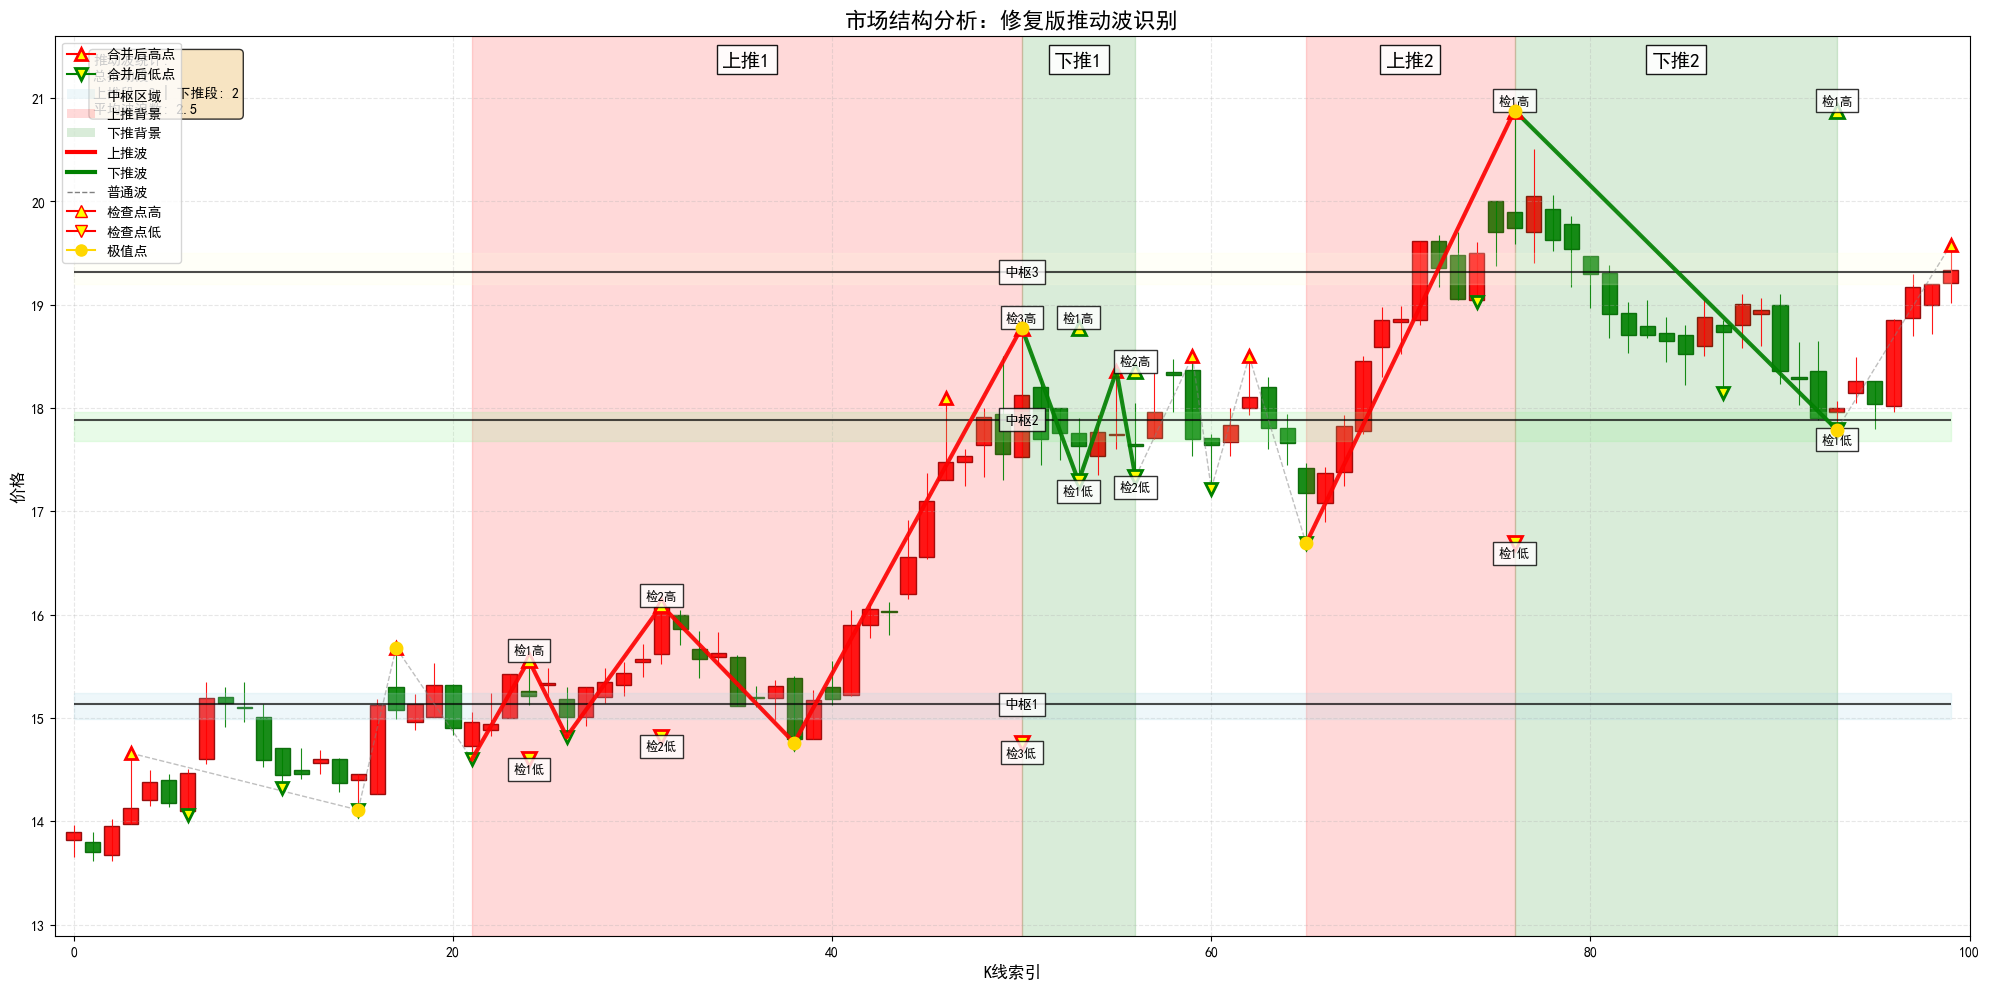


=== 修复版推动波分析结果 ===

上推1: 5个波浪, 3个检查点
  K线范围: 21-50
  价格范围: 14.600 -> 18.780
  检查点1-2: 高点+0.530, 低点+0.220
  检查点2-3: 高点+2.690, 低点+-0.060

下推1: 3个波浪, 2个检查点
  K线范围: 50-56
  价格范围: 18.780 -> 17.330
  检查点1-2: 高点-0.420, 低点--0.040

上推2: 1个波浪, 1个检查点
  K线范围: 65-76
  价格范围: 16.690 -> 20.880

下推2: 1个波浪, 1个检查点
  K线范围: 76-93
  价格范围: 20.880 -> 17.790


In [ ]:
import matplotlib.patches as patches
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import argrelextrema
import pandas as pd
import matplotlib
from sklearn.cluster import KMeans
import os
from pathlib import Path

# 设置中文字体
matplotlib.rcParams['font.sans-serif'] = ['SimHei']
matplotlib.rcParams['axes.unicode_minus'] = False

def detect_high_low_points(df, window=2):
    """
    可靠检测高点和低点极点
    """
    if 'high' not in df.columns or 'low' not in df.columns:
        raise ValueError("DataFrame必须包含'high'和'low'列")
    
    high_prices = df['high'].values
    low_prices = df['low'].values
    
    # 检测高点（局部最大值）
    high_indices = argrelextrema(high_prices, np.greater, order=window)[0]
    # 检测低点（局部最小值）
    low_indices = argrelextrema(low_prices, np.less, order=window)[0]
    
    # 检查窗口的第一个和最后一个点是否是极值
    if len(df) > 0:
        if len(high_prices) > 0 and high_prices[0] >= max(high_prices[:min(3, len(high_prices))]):
            if 0 not in high_indices:
                high_indices = np.insert(high_indices, 0, 0)
        
        if len(low_prices) > 0 and low_prices[0] <= min(low_prices[:min(3, len(low_prices))]):
            if 0 not in low_indices:
                low_indices = np.insert(low_indices, 0, 0)
        
        if len(high_prices) > 0 and high_prices[-1] >= max(high_prices[-min(3, len(high_prices)):]):
            if len(high_prices)-1 not in high_indices:
                high_indices = np.append(high_indices, len(high_prices)-1)
        
        if len(low_prices) > 0 and low_prices[-1] <= min(low_prices[-min(3, len(low_prices)):]):
            if len(low_prices)-1 not in low_indices:
                low_indices = np.append(low_indices, len(low_prices)-1)
    
    # 创建标记列
    df = df.copy()
    df['is_high'] = False
    df['is_low'] = False
    df['is_extreme_high'] = False
    df['is_extreme_low'] = False
    
    # 标记高点和低点
    df.iloc[high_indices, df.columns.get_loc('is_high')] = True
    df.iloc[low_indices, df.columns.get_loc('is_low')] = True
    
    # 检测极高点
    if len(high_indices) >= 3:
        for i in range(1, len(high_indices) - 1):
            prev_idx = high_indices[i-1]
            current_idx = high_indices[i]
            next_idx = high_indices[i+1]
            
            current_high = high_prices[current_idx]
            prev_high = high_prices[prev_idx]
            next_high = high_prices[next_idx]
            
            if current_high > prev_high and current_high > next_high:
                df.iloc[current_idx, df.columns.get_loc('is_extreme_high')] = True
    
    # 检测极低点
    if len(low_indices) >= 3:
        for i in range(1, len(low_indices) - 1):
            prev_idx = low_indices[i-1]
            current_idx = low_indices[i]
            next_idx = low_indices[i+1]
            
            current_low = low_prices[current_idx]
            prev_low = low_prices[prev_idx]
            next_low = low_prices[next_idx]
            
            if current_low < prev_low and current_low < next_low:
                df.iloc[current_idx, df.columns.get_loc('is_extreme_low')] = True
    
    return df

def mark_extremes_in_merged_points(merged_points, df):
    """
    在 merge_nearby_points 输出的 points 列表中：
    - 找出连续的 high 或 low 段；
    - 若段内无极值，则将最值点标记为极值（通过修改 df）。
    """
    if len(merged_points) == 0:
        return

    # 确保 df 有极值列
    if 'is_extreme_high' not in df.columns:
        df['is_extreme_high'] = False
    if 'is_extreme_low' not in df.columns:
        df['is_extreme_low'] = False

    i = 0
    n = len(merged_points)
    
    while i < n:
        curr_type = merged_points[i][1]
        segment = []
        j = i
        
        # 收集连续同类型点
        while j < n and merged_points[j][1] == curr_type:
            segment.append(merged_points[j])
            j += 1
        
        # 检查这段是否已有极值
        has_extreme = False
        for idx, pt_type, price in segment:
            if pt_type == 'high':
                if df.iloc[idx]['is_extreme_high']:
                    has_extreme = True
                    break
            else:
                if df.iloc[idx]['is_extreme_low']:
                    has_extreme = True
                    break
        
        # 如果没有极值，且长度 >= 2，标记最值
        if not has_extreme and len(segment) >= 2:
            if curr_type == 'high':
                # 找最高价
                max_pt = max(segment, key=lambda x: x[2])
                df.iloc[max_pt[0], df.columns.get_loc('is_extreme_high')] = True
            else:  # low
                min_pt = min(segment, key=lambda x: x[2])
                df.iloc[min_pt[0], df.columns.get_loc('is_extreme_low')] = True
        
        i = j  # 跳到下一段

def merge_nearby_points(points, centers, price_range, merge_threshold=0.05):
    """
    合并中枢附近的高低点
    """
    if not points or not centers:
        return points
    
    merge_distance = price_range * merge_threshold
    
    merged_points = []
    i = 0
    
    while i < len(points):
        current_point = points[i]
        current_idx, current_type, current_price = current_point
        
        near_center = False
        for center in centers:
            if abs(current_price - center) <= merge_distance:
                near_center = True
                break
        
        if near_center:
            group = [current_point]
            j = i + 1
            
            while j < len(points):
                next_point = points[j]
                next_idx, next_type, next_price = next_point
                
                next_near_center = False
                for center in centers:
                    if abs(next_price - center) <= merge_distance:
                        next_near_center = True
                        break
                
                if next_near_center and next_type == current_type:
                    group.append(next_point)
                    j += 1
                else:
                    break
            
            if len(group) > 1:
                merged_points.append(group[0])
                merged_points.append(group[-1])
            else:
                merged_points.append(current_point)
            
            i = j
        else:
            merged_points.append(current_point)
            i += 1
    
    return merged_points

def simple_connect_points(points, df_with_high_low):
    """
    波浪连接：从当前点出发，向后找到下一个反向类型段，
    在该段中：优先连第一个极值点，否则连最后一个点。
    连接后，从目标点继续，中间全部跳过。
    """
    if len(points) < 2:
        return []

    waves = []
    i = 0
    n = len(points)

    while i < n:
        curr_idx, curr_type, curr_price = points[i]
        target_type = 'low' if curr_type == 'high' else 'high'

        # Step 1: 找到从 i+1 开始的第一个 target_type 段（连续的）
        j = i + 1
        # 跳过非 target_type 的点（理论上不会出现，但保险）
        while j < n and points[j][1] != target_type:
            j += 1
        
        if j >= n:
            break  # 没有目标类型了

        # Step 2: 收集整个连续的 target_type 段
        segment_start = j
        while j < n and points[j][1] == target_type:
            j += 1
        segment_end = j  # segment is [segment_start, segment_end)

        target_segment = points[segment_start:segment_end]

        # Step 3: 在 segment 中找第一个极值点
        target_point = None
        for pt in target_segment:
            pt_idx, pt_type, pt_price = pt
            is_extreme = False
            if pt_type == 'high':
                is_extreme = df_with_high_low.iloc[pt_idx]['is_extreme_high']
            else:
                is_extreme = df_with_high_low.iloc[pt_idx]['is_extreme_low']
            
            if is_extreme:
                target_point = pt
                break
        
        # 如果没极值，取 segment 最后一个点
        if target_point is None:
            target_point = target_segment[-1]

        # Step 4: 创建波浪
        if curr_type == 'low':
            wave = {
                'start_idx': curr_idx,
                'end_idx': target_point[0],
                'start_type': 'low',
                'end_type': 'high',
                'direction': 'up',
                'start_price': curr_price,
                'end_price': target_point[2],
                'height': target_point[2] - curr_price
            }
        else:
            wave = {
                'start_idx': curr_idx,
                'end_idx': target_point[0],
                'start_type': 'high',
                'end_type': 'low',
                'direction': 'down',
                'start_price': curr_price,
                'end_price': target_point[2],
                'height': curr_price - target_point[2]
            }
        waves.append(wave)

        # Step 5: 找到 target_point 在 points 中的索引，作为下一次起点
        next_i = segment_start
        while next_i < segment_end and points[next_i] != target_point:
            next_i += 1
        
        if next_i >= segment_end:
            next_i = segment_end - 1  # fallback to last

        i = next_i  # 从目标点继续

    return waves

def identify_waves_from_points(points, df_with_high_low):
    """
    从高低点序列识别波浪
    """
    if len(points) < 2:
        return []
    
    # 使用简单连接方法
    waves = simple_connect_points(points, df_with_high_low)
    
    # 为波浪编号
    for i, wave in enumerate(waves):
        wave['wave_number'] = i + 1
    
    return waves

class KLineCenterAnalyzer:
    def __init__(self, window=5, shadow_ratio=0.7, min_zone_separation=0.02, 
                 max_zone_width_ratio=0.1, entity_size_threshold=0.05):
        self.window = window
        self.shadow_ratio = shadow_ratio
        self.min_zone_separation = min_zone_separation
        self.max_zone_width_ratio = max_zone_width_ratio
        self.entity_size_threshold = entity_size_threshold
    
    def is_bullish(self, open_price, close_price):
        """判断是否为阳线"""
        return close_price >= open_price
    
    def calculate_shadow_ratio(self, open_price, high_price, low_price, close_price):
        """计算影线比例"""
        body_size = abs(close_price - open_price)
        upper_shadow = high_price - max(open_price, close_price)
        lower_shadow = min(open_price, close_price) - low_price
        
        if body_size == 0:
            return upper_shadow, lower_shadow, 0
        
        return upper_shadow, lower_shadow, max(upper_shadow, lower_shadow) / body_size
    
    def find_reversal_points(self, df):
        """寻找K线反转点"""
        reversal_points = []
        opens = df['open'].values
        highs = df['high'].values
        lows = df['low'].values
        closes = df['close'].values
        
        for i in range(1, len(opens)-1):
            # 检查颜色反转
            prev_bullish = self.is_bullish(opens[i-1], closes[i-1])
            curr_bullish = self.is_bullish(opens[i], closes[i])
            next_bullish = self.is_bullish(opens[i+1], closes[i+1])
            
            # 颜色反转点
            if (prev_bullish != curr_bullish) or (curr_bullish != next_bullish):
                reversal_points.append(('color_reversal', i, closes[i]))
            
            # 检查影线反转
            _, _, ratio_curr = self.calculate_shadow_ratio(
                opens[i], highs[i], lows[i], closes[i])
            
            # 影线比例超过阈值，可能是反转点
            if ratio_curr > self.shadow_ratio:
                upper_shadow, lower_shadow, _ = self.calculate_shadow_ratio(
                    opens[i], highs[i], lows[i], closes[i])
                
                if upper_shadow > lower_shadow:
                    reversal_points.append(('upper_shadow', i, highs[i]))
                else:
                    reversal_points.append(('lower_shadow', i, lows[i]))
        
        return reversal_points
    
    def find_volume_price_points(self, df):
        """寻找成交量极值点对应的K线价格"""
        volumes = df['volume'].values
        closes = df['close'].values
        
        # 寻找成交量局部高点
        volume_high_idx = argrelextrema(volumes, np.greater, order=self.window)[0]
        
        volume_points = []
        for idx in volume_high_idx:
            volume_points.append(('volume_price', idx, closes[idx]))
        
        return volume_points
    
    def cluster_prices(self, points, n_clusters=3):
        """对价格点进行聚类，返回聚类中心"""
        if not points:
            return []
            
        prices = np.array([point[2] for point in points]).reshape(-1, 1)
        
        if len(prices) <= n_clusters:
            return sorted([p[0] for p in prices])
        
        kmeans = KMeans(n_clusters=min(n_clusters, len(prices)), random_state=0).fit(prices)
        centers = sorted([center[0] for center in kmeans.cluster_centers_])
        return centers
    
    def find_centers(self, df):
        """找出中枢水平线"""
        reversal_points = self.find_reversal_points(df)
        volume_points = self.find_volume_price_points(df)
        
        all_points = reversal_points + volume_points
        
        if not all_points:
            return [], [], []
        
        center_lines = self.cluster_prices(all_points, 3)
        
        return center_lines, reversal_points, volume_points
    
    def calculate_center_zones(self, df, center_lines):
        """计算中枢区域，确保不重叠"""
        center_zones = []
        opens = df['open'].values
        highs = df['high'].values
        lows = df['low'].values
        closes = df['close'].values
        
        price_range = np.max(highs) - np.min(lows)
        min_separation = price_range * self.min_zone_separation
        max_zone_width = price_range * self.max_zone_width_ratio
        
        entity_sizes = np.abs(closes - opens)
        entity_size_threshold = np.percentile(entity_sizes, 95)
        
        for center_line in center_lines:
            crossing_k_lines = []
            for i in range(len(df)):
                if lows[i] <= center_line <= highs[i]:
                    entity_high = max(opens[i], closes[i])
                    entity_low = min(opens[i], closes[i])
                    entity_size = entity_high - entity_low
                    
                    if entity_size <= entity_size_threshold:
                        crossing_k_lines.append((entity_high, entity_low))
            
            if crossing_k_lines:
                entity_highs = [h for h, l in crossing_k_lines]
                entity_lows = [l for h, l in crossing_k_lines]
                
                zone_high = np.mean(entity_highs)
                zone_low = np.mean(entity_lows)
                
                min_zone_height = price_range * 0.005
                if zone_high - zone_low < min_zone_height:
                    mid_point = (zone_high + zone_low) / 2
                    zone_high = mid_point + min_zone_height / 2
                    zone_low = mid_point - min_zone_height / 2
                
                if zone_high - zone_low > max_zone_width:
                    mid_point = (zone_high + zone_low) / 2
                    zone_high = mid_point + max_zone_width / 2
                    zone_low = mid_point - max_zone_width / 2
                
                overlap_found = False
                for i, (existing_center, existing_low, existing_high, existing_count) in enumerate(center_zones):
                    if not (zone_high < existing_low or zone_low > existing_high):
                        # 发现重叠，合并区域
                        merged_low = min(zone_low, existing_low)
                        merged_high = max(zone_high, existing_high)
                        
                        if merged_high - merged_low > max_zone_width:
                            mid_point = (merged_low + merged_high) / 2
                            merged_low = mid_point - max_zone_width / 2
                            merged_high = mid_point + max_zone_width / 2
                        
                        merged_center = (center_line + existing_center) / 2
                        merged_count = len(crossing_k_lines) + existing_count
                        
                        center_zones[i] = (merged_center, merged_low, merged_high, merged_count)
                        overlap_found = True
                        break
                
                if not overlap_found:
                    center_zones.append((center_line, zone_low, zone_high, len(crossing_k_lines)))
        
        # 确保区域之间有最小分离距离，防止重叠
        center_zones.sort(key=lambda x: x[0])
        
        non_overlapping_zones = []
        for zone in center_zones:
            center_line, zone_low, zone_high, count = zone
            
            if not non_overlapping_zones:
                non_overlapping_zones.append(zone)
                continue
                
            # 检查是否与已有区域重叠
            overlaps = False
            for existing_zone in non_overlapping_zones:
                existing_center, existing_low, existing_high, existing_count = existing_zone
                
                if not (zone_high < existing_low or zone_low > existing_high):
                    # 有重叠，跳过这个区域
                    overlaps = True
                    break
            
            if not overlaps:
                non_overlapping_zones.append(zone)
        
        # 按中心线排序
        non_overlapping_zones.sort(key=lambda x: x[0])
        
        return non_overlapping_zones


def identify_impulse_waves_vectorized(waves, df):
    """
    顺序识别推动波：先正常三波识别，再考虑单波成段（仅基于高度排名）
    """
    if len(waves) < 1:
        return []
    
    impulse_segments = []
    i = 0
    push_count_up = 0
    push_count_down = 0
    last_push_direction = None
    
    # 预处理波浪的高低点
    for wave in waves:
        if wave['direction'] == 'up':
            wave['high_point'] = wave['end_price']
            wave['low_point'] = wave['start_price']
            wave['range'] = wave['end_price'] - wave['start_price']
        else:
            wave['high_point'] = wave['start_price']
            wave['low_point'] = wave['end_price']
            wave['range'] = wave['start_price'] - wave['end_price']
    
    print(f"总波浪数: {len(waves)}")
    
    # 计算波浪高度排名
    wave_ranges = [wave['range'] for wave in waves]
    sorted_ranges = sorted(wave_ranges, reverse=True)
    top_20_percent_index = max(1, len(waves) // 5)  # 前20%的阈值索引
    height_threshold = sorted_ranges[top_20_percent_index - 1] if sorted_ranges else 0
    
    print(f"波浪高度阈值(前20%): {height_threshold:.4f}")
    print(f"所有波浪高度范围: {[f'{r:.4f}' for r in sorted_ranges]}")
    
    while i < len(waves):
        print(f"\n检查位置: 波{i+1}({waves[i]['direction']}), 高度: {waves[i]['range']:.4f}")
        
        # 第一步：尝试正常三波识别
        normal_push = None
        if i <= len(waves) - 3:
            normal_push = try_normal_three_wave(waves, i, last_push_direction)
        
        if normal_push:
            # 找到正常三波推动段
            if normal_push['direction'] == 'up':
                push_count_up += 1
                push_number = push_count_up
            else:
                push_count_down += 1
                push_number = push_count_down
            
            impulse_segment = {
                'push_number': push_number,
                'direction': normal_push['direction'],
                'waves': normal_push['waves'],
                'start_idx': normal_push['start_idx'],
                'end_idx': normal_push['end_idx'],
                'start_price': normal_push['start_price'],
                'end_price': normal_push['end_price'],
                'type': 'normal_three_wave',
                'used_tolerance': normal_push.get('used_tolerance', False)
            }
            
            impulse_segments.append(impulse_segment)
            last_push_direction = normal_push['direction']
            i = normal_push['end_wave_index'] + 1
            print(f"  找到正常三波推动段: {normal_push['direction']}{push_number}, 跳到波{i+1}")
            
        else:
            # 第二步：尝试单波成段 - 仅基于高度排名
            single_push = try_single_wave_by_height(waves, i, last_push_direction, height_threshold)
            
            if single_push:
                if single_push['direction'] == 'up':
                    push_count_up += 1
                    push_number = push_count_up
                else:
                    push_count_down += 1
                    push_number = push_count_down
                
                impulse_segment = {
                    'push_number': push_number,
                    'direction': single_push['direction'],
                    'waves': single_push['waves'],
                    'start_idx': single_push['start_idx'],
                    'end_idx': single_push['end_idx'],
                    'start_price': single_push['start_price'],
                    'end_price': single_push['end_price'],
                    'type': 'single_wave',
                    'height_rank_percentile': single_push['height_rank_percentile'],
                    'used_tolerance': single_push.get('used_tolerance', False)
                }
                
                impulse_segments.append(impulse_segment)
                last_push_direction = single_push['direction']
                i += 1  # 单波只占用当前波浪
                print(f"  找到单波推动段: {single_push['direction']}{push_number}, 高度排名: {single_push['height_rank_percentile']:.1f}%")
            else:
                # 都不满足，移动到下一个波浪
                print(f"  未找到推动段，滑动到波{i+2}")
                i += 1
    
    print(f"\n识别完成，找到{len(impulse_segments)}个推动段")
    return impulse_segments

def try_single_wave_by_height(waves, current_index, last_push_direction, height_threshold):
    """基于高度排名尝试单波成段"""
    current_wave = waves[current_index]
    
    # 检查高度是否达到前20%
    if current_wave['range'] < height_threshold:
        print(f"  单波高度 {current_wave['range']:.4f} < 阈值 {height_threshold:.4f}，不符合")
        return None
    
    # 计算高度百分位排名
    all_ranges = [w['range'] for w in waves]
    sorted_ranges = sorted(all_ranges)
    rank = sorted_ranges.index(current_wave['range'])
    percentile = (rank / len(sorted_ranges)) * 100
    
    print(f"  单波高度排名: {percentile:.1f}% (排名{rank+1}/{len(sorted_ranges)})")
    
    # 检查方向交替
    if last_push_direction is not None and current_wave['direction'] == last_push_direction:
        print(f"  方向与上一个推动段相同({last_push_direction})，不符合交替规则")
        return None
    
    # 创建单波推动段
    single_push = {
        'direction': current_wave['direction'],
        'waves': [current_wave],
        'start_idx': current_wave['start_idx'],
        'end_idx': current_wave['end_idx'],
        'start_price': current_wave['start_price'],
        'end_price': current_wave['end_price'],
        'height_rank_percentile': percentile,
        'used_tolerance': False
    }
    
    return single_push

def try_normal_three_wave(waves, start_index, last_push_direction):
    """尝试识别正常的三波推动段"""
    wave1 = waves[start_index]
    wave2 = waves[start_index + 1]
    wave3 = waves[start_index + 2]
    
    # 计算大窗口价格范围
    window_high = max(wave1['high_point'], wave2['high_point'], wave3['high_point'])
    window_low = min(wave1['low_point'], wave2['low_point'], wave3['low_point'])
    window_range = window_high - window_low
    
    # 严格检查条件
    is_rising = (wave1['direction'] == 'up' and wave3['direction'] == 'up' and
                wave3['high_point'] > wave1['high_point'] and 
                wave3['low_point'] > wave1['low_point'])
    
    is_falling = (wave1['direction'] == 'down' and wave3['direction'] == 'down' and
                 wave3['high_point'] < wave1['high_point'] and 
                 wave3['low_point'] < wave1['low_point'])
    
    print(f"  三波检查 - 上升: {is_rising}, 下降: {is_falling}")
    
    # 如果严格检查不通过，但预期是反向段，应用过冲容忍
    used_tolerance = False
    if not is_rising and not is_falling and last_push_direction is not None:
        expected_direction = 'down' if last_push_direction == 'up' else 'up'
        current_direction = 'up' if (wave1['direction'] == 'up' and wave3['direction'] == 'up') else 'down'
        
        if expected_direction == current_direction:
            print("  应用反向段过冲容忍")
            if current_direction == 'up':
                high_diff = wave3['high_point'] - wave1['high_point']
                low_diff = wave3['low_point'] - wave1['low_point']
                high_diff_ratio = high_diff / window_range
                low_diff_ratio = low_diff / window_range
                
                condition1 = (high_diff_ratio > 0.05 and abs(low_diff_ratio) < 0.1)
                condition2 = (low_diff_ratio > 0.05 and abs(high_diff_ratio) < 0.1)
                
                if condition1 or condition2:
                    is_rising = True
                    used_tolerance = True
                    print(f"    上升容忍通过: 条件1={condition1}, 条件2={condition2}")
            
            else:  # current_direction == 'down'
                high_diff = wave1['high_point'] - wave3['high_point']
                low_diff = wave1['low_point'] - wave3['low_point']
                high_diff_ratio = high_diff / window_range
                low_diff_ratio = low_diff / window_range
                
                condition1 = (high_diff_ratio > 0.05 and abs(low_diff_ratio) < 0.1)
                condition2 = (low_diff_ratio > 0.05 and abs(high_diff_ratio) < 0.1)
                
                if condition1 or condition2:
                    is_falling = True
                    used_tolerance = True
                    print(f"    下降容忍通过: 条件1={condition1}, 条件2={condition2}")
    
    if is_rising or is_falling:
        direction = 'up' if is_rising else 'down'
        
        # 扩展推动段（深度优先）
        end_index = start_index + 2
        waves_in_push = [wave1, wave2, wave3]
        
        current_index = start_index + 2
        while current_index <= len(waves) - 3:
            next_wave1 = waves[current_index]
            next_wave2 = waves[current_index + 1]
            next_wave3 = waves[current_index + 2]
            
            # 检查是否仍然符合推动规则
            if direction == 'up' and next_wave1['direction'] == 'up' and next_wave3['direction'] == 'up':
                still_valid = (next_wave3['high_point'] > next_wave1['high_point'] and 
                              next_wave3['low_point'] > next_wave1['low_point'])
                
                if not still_valid:
                    # 应用过冲检查
                    next_window_high = max(next_wave1['high_point'], next_wave2['high_point'], next_wave3['high_point'])
                    next_window_low = min(next_wave1['low_point'], next_wave2['low_point'], next_wave3['low_point'])
                    next_window_range = next_window_high - next_window_low
                    
                    high_diff = next_wave3['high_point'] - next_wave1['high_point']
                    low_diff = next_wave3['low_point'] - next_wave1['low_point']
                    high_diff_ratio = high_diff / next_window_range
                    low_diff_ratio = low_diff / next_window_range
                    
                    condition1 = (high_diff_ratio > 0.05 and abs(low_diff_ratio) < 0.1)
                    condition2 = (low_diff_ratio > 0.05 and abs(high_diff_ratio) < 0.1)
                    
                    if condition1 or condition2:
                        still_valid = True
                        print(f"    扩展段过冲容忍: 波{current_index+1}到波{current_index+3}")
                
            elif direction == 'down' and next_wave1['direction'] == 'down' and next_wave3['direction'] == 'down':
                still_valid = (next_wave3['high_point'] < next_wave1['high_point'] and 
                              next_wave3['low_point'] < next_wave1['low_point'])
                
                if not still_valid:
                    # 应用过冲检查
                    next_window_high = max(next_wave1['high_point'], next_wave2['high_point'], next_wave3['high_point'])
                    next_window_low = min(next_wave1['low_point'], next_wave2['low_point'], next_wave3['low_point'])
                    next_window_range = next_window_high - next_window_low
                    
                    high_diff = next_wave1['high_point'] - next_wave3['high_point']
                    low_diff = next_wave1['low_point'] - next_wave3['low_point']
                    high_diff_ratio = high_diff / next_window_range
                    low_diff_ratio = low_diff / next_window_range
                    
                    condition1 = (high_diff_ratio > 0.05 and abs(low_diff_ratio) < 0.1)
                    condition2 = (low_diff_ratio > 0.05 and abs(high_diff_ratio) < 0.1)
                    
                    if condition1 or condition2:
                        still_valid = True
                        print(f"    扩展段过冲容忍: 波{current_index+1}到波{current_index+3}")
            else:
                still_valid = False
            
            if still_valid:
                waves_in_push.extend([waves[current_index + 1], waves[current_index + 2]])
                end_index = current_index + 2
                current_index += 2
            else:
                break
        
        return {
            'direction': direction,
            'waves': waves_in_push,
            'start_idx': wave1['start_idx'],
            'end_idx': waves[end_index]['end_idx'],
            'start_price': wave1['start_price'],
            'end_price': waves[end_index]['end_price'],
            'end_wave_index': end_index,
            'used_tolerance': used_tolerance
        }
    
    return None


def visualize_market_structure_with_impulse(df, start_date=None, end_date=None):
    """可视化市场结构：包含推动波识别 - 修复版"""
    # 重置索引为连续整数索引
    df = df.reset_index(drop=True)
    
    # 设置中文字体
    matplotlib.rcParams['font.sans-serif'] = ['SimHei']
    matplotlib.rcParams['axes.unicode_minus'] = False
    
    # 确定数据范围
    if start_date is not None:
        start_date = pd.to_datetime(start_date)
        df = df[df.index >= start_date]
    if end_date is not None:
        end_date = pd.to_datetime(end_date)
        df = df[df.index <= end_date]
    
    if len(df) == 0:
        print("所选日期范围内无数据")
        return None
    
    # 1. 先找中枢
    analyzer = KLineCenterAnalyzer()
    center_lines, reversal_points, volume_points = analyzer.find_centers(df)
    center_zones = analyzer.calculate_center_zones(df, center_lines)
    
    # 2. 再找高低点
    df_with_high_low = detect_high_low_points(df)
    
    # 获取所有高低点
    high_points = [(idx, 'high', df.iloc[idx]['high']) for idx in df_with_high_low[df_with_high_low['is_high']].index]
    low_points = [(idx, 'low', df.iloc[idx]['low']) for idx in df_with_high_low[df_with_high_low['is_low']].index]
    
    # 合并高低点并按索引排序
    all_points = sorted(high_points + low_points, key=lambda x: x[0])
    
    # 3. 合并中枢附近的高低点
    price_range = df['high'].max() - df['low'].min()
    merged_points = merge_nearby_points(all_points, center_lines, price_range)
    # 在合并后的点序列中补全极值
    mark_extremes_in_merged_points(merged_points, df_with_high_low)
    
    # 4. 从合并后的点识别波浪
    waves = identify_waves_from_points(merged_points, df_with_high_low)
    
    # 5. 使用修复版向量化方式识别推动波
    impulse_segments = identify_impulse_waves_vectorized(waves, df_with_high_low)
    impulse_stats = get_impulse_statistics(impulse_segments)
    
    # 创建图形
    fig, ax = plt.subplots(figsize=(20, 10))
    
    # 设置坐标轴范围
    price_padding = price_range * 0.1
    y_min = df['low'].min() - price_padding
    y_max = df['high'].max() + price_padding
    ax.set_ylim(y_min, y_max)
    
    # 绘制K线图
    x = np.arange(len(df))
    opens = df['open'].values
    highs = df['high'].values
    lows = df['low'].values
    closes = df['close'].values
    
    # 分离阳线和阴线
    up_indices = closes >= opens
    down_indices = closes < opens
    
    # 阳线 - 红色
    if np.any(up_indices):
        up_x = x[up_indices]
        up_highs = highs[up_indices]
        up_lows = lows[up_indices]
        up_opens = opens[up_indices]
        up_closes = closes[up_indices]
        
        ax.vlines(up_x, up_lows, up_highs, color='red', linewidth=0.8, alpha=0.9)
        ax.bar(up_x, up_closes - up_opens, 0.8, up_opens, 
               color='red', edgecolor='darkred', alpha=0.9)
    
    # 阴线 - 绿色
    if np.any(down_indices):
        down_x = x[down_indices]
        down_highs = highs[down_indices]
        down_lows = lows[down_indices]
        down_opens = opens[down_indices]
        down_closes = closes[down_indices]
        
        ax.vlines(down_x, down_lows, down_highs, color='green', linewidth=0.8, alpha=0.9)
        ax.bar(down_x, down_closes - down_opens, 0.8, down_opens, 
               color='green', edgecolor='darkgreen', alpha=0.9)

    # 绘制原始高低点（浅色）
    high_points_pre = df_with_high_low[df_with_high_low['is_high']]
    low_points_pre = df_with_high_low[df_with_high_low['is_low']]
    
    ax.plot(high_points_pre.index, high_points_pre['high'], '^', color='blue', markersize=4, 
             alpha=0.3, zorder=5)
    ax.plot(low_points_pre.index, low_points_pre['low'], 'v', color='purple', markersize=4, 
             alpha=0.3, zorder=5)
    
    # 标记合并后的高低点
    for idx, point_type, price in merged_points:
        if point_type == 'high':
            ax.plot(idx, price, '^', color='red', markersize=8, 
                    markeredgewidth=2, markerfacecolor='yellow', zorder=6)
        else:
            ax.plot(idx, price, 'v', color='green', markersize=8, 
                    markeredgewidth=2, markerfacecolor='yellow', zorder=6)
    
    # 绘制中枢区域
    colors = ['lightblue', 'lightgreen', 'lightyellow', 'lightcoral', 'lightcyan']
    for i, (center_line, zone_low, zone_high, k_line_count) in enumerate(center_zones):
        start_idx = 0
        end_idx = len(df) - 1
        
        color_idx = i % len(colors)
        rect = patches.Rectangle(
            (start_idx, zone_low),
            end_idx - start_idx,
            zone_high - zone_low,
            alpha=0.2, color=colors[color_idx], zorder=2
        )
        ax.add_patch(rect)
        
        # 绘制中枢中心线
        ax.hlines(center_line, start_idx, end_idx, 
                 colors='black', linestyles='-', linewidth=1.5, alpha=0.7, zorder=3)
        
        # 标注中枢
        ax.text(
            len(df) / 2,
            center_line,
            f'中枢{i+1}',
            fontsize=10, ha='center', va='center', 
            bbox=dict(facecolor='white', alpha=0.8), zorder=5
        )
    
    # 绘制所有波浪（灰色虚线）
    for wave in waves:
        start_idx = wave['start_idx']
        end_idx = wave['end_idx']
        start_price = wave['start_price']
        end_price = wave['end_price']
        direction = wave['direction']
        wave_number = wave['wave_number']
        
        color = 'gray'
        linestyle = '--'
        linewidth = 1
        alpha = 0.5
        
        ax.plot([start_idx, end_idx], [start_price, end_price], 
                color=color, linestyle=linestyle, linewidth=linewidth, alpha=alpha, zorder=4)
    
    # 绘制推动波（突出显示）并添加阴影背景
    for segment in impulse_segments:
        push_number = segment['push_number']
        direction = segment['direction']
        waves_in_segment = segment['waves']
        
        # 为每个推动波段选择颜色
        if direction == 'up':
            wave_color = 'red'
            bg_color = 'rgba(255, 0, 0, 0.1)'
            push_text = f'上推{push_number}'
        else:
            wave_color = 'green'
            bg_color = 'rgba(0, 255, 0, 0.1)'
            push_text = f'下推{push_number}'
        
        # 修复1：添加阴影背景
        start_idx = segment['start_idx']
        end_idx = segment['end_idx']
        rect = patches.Rectangle(
            (start_idx, y_min),
            end_idx - start_idx,
            y_max - y_min,
            alpha=0.15, color=wave_color, zorder=1
        )
        ax.add_patch(rect)
        
        # 绘制推动波线段
        for wave in waves_in_segment:
            start_idx = wave['start_idx']
            end_idx = wave['end_idx']
            start_price = wave['start_price']
            end_price = wave['end_price']
            
            # 推动波用实线和更粗的线宽
            ax.plot([start_idx, end_idx], [start_price, end_price], 
                    color=wave_color, linestyle='-', linewidth=3, alpha=0.9, zorder=6)
        
        # 标记推动波的检查点（第1、3、5...个波）
        check_waves = [waves_in_segment[i] for i in range(0, len(waves_in_segment), 2)]
        for j, check_wave in enumerate(check_waves):
            # 获取检查波的高低点
            if check_wave['direction'] == 'up':
                high_point = check_wave['end_price']
                low_point = check_wave['start_price']
            else:
                high_point = check_wave['start_price']
                low_point = check_wave['end_price']
            
            # 标记检查点
            check_idx = check_wave['end_idx']
            ax.plot(check_idx, high_point, '^', 
                   color=wave_color, markersize=10, markeredgewidth=2, 
                   markerfacecolor='yellow', zorder=7)
            ax.plot(check_idx, low_point, 'v', 
                   color=wave_color, markersize=10, markeredgewidth=2, 
                   markerfacecolor='yellow', zorder=7)
            
            # 标记检查编号
            ax.text(check_idx, high_point + price_padding * 0.05, f'检{j+1}高',
                   fontsize=9, ha='center', va='bottom', fontweight='bold',
                   bbox=dict(facecolor='white', alpha=0.8), zorder=7)
            ax.text(check_idx, low_point - price_padding * 0.05, f'检{j+1}低',
                   fontsize=9, ha='center', va='top', fontweight='bold',
                   bbox=dict(facecolor='white', alpha=0.8), zorder=7)
        
        # 标记是否跳过了小波
        if segment.get('skipped_small_wave', False):
            push_text += " (跳小波)"
    
        # 在推动波段上方标记总的推动编号
        segment_mid_x = (segment['start_idx'] + segment['end_idx']) / 2
        ax.text(segment_mid_x, y_max - price_padding * 0.2, push_text,
                fontsize=14, ha='center', va='top', fontweight='bold',
                bbox=dict(facecolor='white', alpha=0.9), zorder=8)
    
    # 标记极值点
    extreme_high_points = df_with_high_low[df_with_high_low['is_extreme_high']]
    extreme_low_points = df_with_high_low[df_with_high_low['is_extreme_low']]
    
    ax.plot(extreme_high_points.index, extreme_high_points['high'], 'o', 
            color='gold', markersize=8, markeredgewidth=2, zorder=7)
    ax.plot(extreme_low_points.index, extreme_low_points['low'], 'o', 
            color='gold', markersize=8, markeredgewidth=2, zorder=7)
    
    # 设置主图格式
    ax.set_title('市场结构分析：修复版推动波识别', fontsize=16, fontweight='bold')
    ax.set_ylabel('价格', fontsize=12)
    ax.set_xlabel('K线索引', fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.3, zorder=0)
    ax.set_xlim(-1, len(df))
    
    # 创建图例
    legend_elements = [
        Line2D([0], [0], marker='^', color='red', markerfacecolor='yellow', 
               markersize=8, markeredgewidth=2, label='合并后高点'),
        Line2D([0], [0], marker='v', color='green', markerfacecolor='yellow', 
               markersize=8, markeredgewidth=2, label='合并后低点'),
        patches.Patch(facecolor='lightblue', alpha=0.2, label='中枢区域'),
        patches.Patch(facecolor='red', alpha=0.15, label='上推背景'),
        patches.Patch(facecolor='green', alpha=0.15, label='下推背景'),
        Line2D([0], [0], color='red', linestyle='-', lw=3, label='上推波'),
        Line2D([0], [0], color='green', linestyle='-', lw=3, label='下推波'),
        Line2D([0], [0], color='gray', linestyle='--', lw=1, label='普通波'),
        Line2D([0], [0], marker='^', color='red', markerfacecolor='yellow', 
               markersize=8, label='检查点高'),
        Line2D([0], [0], marker='v', color='red', markerfacecolor='yellow', 
               markersize=8, label='检查点低'),
        Line2D([0], [0], marker='o', color='gold', markerfacecolor='gold', 
               markersize=8, label='极值点')
    ]
    
    ax.legend(handles=legend_elements, loc='upper left', fontsize=10)
    
    # 添加统计信息
    stats_text = f"推动波统计:\n总推动段: {impulse_stats.get('total_impulses', 0)}\n"
    up_segments = [s for s in impulse_segments if s['direction'] == 'up']
    down_segments = [s for s in impulse_segments if s['direction'] == 'down']
    stats_text += f"上推段: {len(up_segments)} | 下推段: {len(down_segments)}\n"
    
    if impulse_segments:
        avg_waves = sum(len(s['waves']) for s in impulse_segments) / len(impulse_segments)
        stats_text += f"平均波浪数: {avg_waves:.1f}"
    
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    plt.tight_layout()
    plt.savefig('market_structure_fixed_impulse.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # 打印推动波详情
    print("\n=== 修复版推动波分析结果 ===")
    for segment in impulse_segments:
        direction_str = "上推" if segment['direction'] == 'up' else "下推"
        check_points = len(segment['waves']) // 2 + 1
        skip_info = " (跳过小波)" if segment.get('skipped_small_wave', False) else ""
        print(f"\n{direction_str}{segment['push_number']}{skip_info}: {len(segment['waves'])}个波浪, {check_points}个检查点")
        print(f"  K线范围: {segment['start_idx']}-{segment['end_idx']}")
        print(f"  价格范围: {segment['start_price']:.3f} -> {segment['end_price']:.3f}")
        
        # 显示检查点的高低点比较
        check_waves = [segment['waves'][i] for i in range(0, len(segment['waves']), 2)]
        for j in range(1, len(check_waves)):
            waveA = check_waves[j-1]
            waveB = check_waves[j]
            
            if segment['direction'] == 'up':
                high_diff = waveB['high_point'] - waveA['high_point']
                low_diff = waveB['low_point'] - waveA['low_point']
                print(f"  检查点{j}-{j+1}: 高点+{high_diff:.3f}, 低点+{low_diff:.3f}")
            else:
                high_diff = waveA['high_point'] - waveB['high_point'] 
                low_diff = waveA['low_point'] - waveB['low_point']
                print(f"  检查点{j}-{j+1}: 高点-{high_diff:.3f}, 低点-{low_diff:.3f}")
    
    return {
        'center_zones': center_zones,
        'waves': waves,
        'impulse_segments': impulse_segments,
        'merged_points': merged_points
    }

def get_impulse_statistics(impulse_segments):
    """获取推动统计信息"""
    if not impulse_segments:
        return {}
    
    up_segments = [s for s in impulse_segments if s['direction'] == 'up']
    down_segments = [s for s in impulse_segments if s['direction'] == 'down']
    
    stats = {
        'total_impulses': len(impulse_segments),
        'up_impulses': len(up_segments),
        'down_impulses': len(down_segments),
        'avg_impulse_bars': sum(s['end_idx'] - s['start_idx'] + 1 for s in impulse_segments) / len(impulse_segments),
        'avg_impulse_height': sum(abs(s['end_price'] - s['start_price']) for s in impulse_segments) / len(impulse_segments),
        'strong_impulses': len([s for s in impulse_segments if len(s['waves']) >= 5]),
        'weak_impulses': len([s for s in impulse_segments if len(s['waves']) <= 3])
    }
    
    return stats

# 使用示例
if __name__ == "__main__":
    # 这里应该是您的数据加载代码
    ts_code = "000001.SZ"
    analysis_dir = 'E:/stock/csv_version/analysis_results'
    csv_path = f"{analysis_dir}/{ts_code}_analysis.csv"
    df = pd.read_csv(csv_path, index_col='trade_date', parse_dates=['trade_date'], nrows=100)
    
    
    # 运行市场结构分析
    result = visualize_market_structure_with_impulse(df)